In [42]:
import numpy as np                                                                        
import matplotlib.pyplot as plt
import pyCloudy as pc
import pyneb as pn
from astropy    import constants as const
from astropy.io import ascii
import pandas as pd
from scipy import interpolate
import warnings
from scipy.integrate import quad, IntegrationWarning
import scipy.integrate as integrate
from numpy import log10, exp
import os
from astropy.constants import c
import astropy.units as u
from scipy import special
import matplotlib.gridspec as gridspec


from scipy.integrate import quad, IntegrationWarning
import scipy.integrate as integrate


from numpy import log10, exp
from CLOUDY_Function import *

kpc = const.kpc.cgs.value

C_IV_K = 1548.187e-8  # cm
C_IV_H = 1550.772e-8  # cm

nu_Lya_K = c_cms / Ly_a_K
nu_Lya_H = c_cms / Ly_a_H

nu_CIV_K = c_cms / C_IV_K 
nu_CIV_H = c_cms / C_IV_H

Ryd_Lya_K = h_ev * nu_Lya_K / 13.6 
Ryd_Lya_H = h_ev * nu_Lya_H / 13.6 

Ryd_CIV_K = h_ev * nu_CIV_K / 13.6 
Ryd_CIV_H = h_ev * nu_CIV_H / 13.6 




In [43]:


Lumin =44.0 # 37.0 - 44.0 + 41.5, 42.5, 43.5 and 44.5
idx_1 = 1 # 1 "" and  2 "no line transfer"
idx_2 = 2
metals = 1.0 # 0.001 - 10.0
Column_density_order = 22.0  # 18.0 - 25.0
mode = 'WO' # 'WO' - 'W'
# path_way = f'/home/jin/RT/CLOUDY_new_Data/Lum_{Lumin}_{idx}/metal_{metals}/N_H_{multi_factor}_{Column_density_order}/QSO_{mode}'

# warnings.filterwarnings('ignore', category=IntegrationWarning)
# warnings.filterwarnings('ignore', category=AttributeError)

cloudy_data_1 = CLOUDY_data(Lumin,idx_1,metals,Column_density_order)
cloudy_data_2 = CLOUDY_data(Lumin,idx_2,metals,Column_density_order)

print('--'*50)
print(f"Lya Luminosity = {cloudy_data_2[f'Lumin_Lya_{Lumin}']:.2e} [erg/s]")

print('--'*50)
print(f"C IV Luminosity = {cloudy_data_2[f'Lumin_CIV_{Lumin}']:.2e} [erg/s]")
print(f"HeII Luminosity = {cloudy_data_2[f'Lumin_HeII_{Lumin}']:.2e} [erg/s]")
print('--'*50)
print(f"C IV Column_density = {cloudy_data_2[f'Column_density_CIV_{Lumin}']:.2e} [cm-2]")
print(f"He II Column_density = {cloudy_data_2[f'Column_density_HeII_{Lumin}']:.2e} [cm-2]")
print('--'*50)

----------------------------------------------------------------------------------------------------
Lya Luminosity = 4.30e+43 [erg/s]
----------------------------------------------------------------------------------------------------
C IV Luminosity = 1.90e+42 [erg/s]
HeII Luminosity = 1.00e+42 [erg/s]
----------------------------------------------------------------------------------------------------
C IV Column_density = 3.59e+17 [cm-2]
He II Column_density = 2.50e+20 [cm-2]
----------------------------------------------------------------------------------------------------


Continuum = 6.00e+40 erg/s/A
Peak = 1.11e+41 erg/s/A
velocity dispersion = 3.00e+03 km/s
lmabda_c = 1546.147079489674 A
Equivalent Width = 50.75 Angstrom
Total Luminosity = 3.04e+42 erg/s


Text(0, 0.5, '$L_{\\lambda}~[\\rm erg \\, s^{-1} \\, \\AA^{-1}]$')

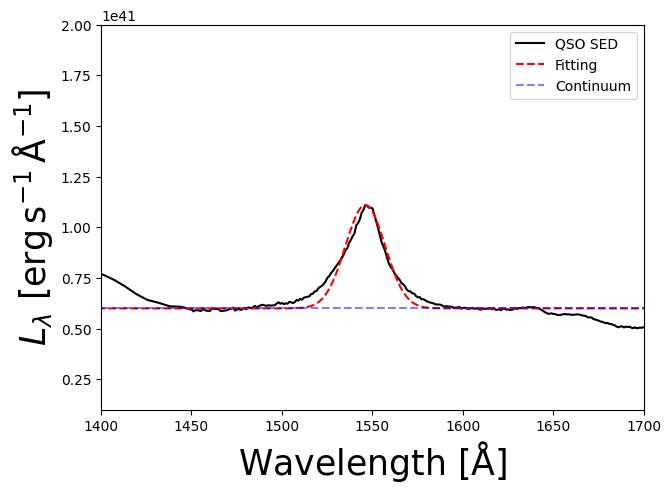

In [44]:
def Flux(Fc,F_max,lam,lam_c,sig_vel):
    del_lam = sig_vel / c_kms  * lam_c
    Flux = (F_max-Fc)*np.exp(- (lam-lam_c)**2 / del_lam**2) + Fc
    return Flux
def EW(Fc,F_max,lam_c,sig_vel):
    del_lam = sig_vel / c_kms  * lam_c
    # print('dlam',del_lam)
    EW =(F_max/ Fc)*np.sqrt(np.pi)*del_lam  # dimension of lambda
    return EW

def Ryd_to_lam(Ryd_x):
    lambda_x = c_cms /  (Ryd_x * 13.6 /h_ev) *1e8


Ryd, Fnu = QSO_SED(path = path(Lumin,2,metals,Column_density_order)) # [1/Hz]
nu = (Ryd * 13.6 /h_ev) # 1/s = Hz
nuFnu = Fnu * nu # dimenionless parameter 

normalized_factor = 10**(Lumin)/nuFnu[np.where(Ryd==1)[0]] # erg/s


fig = plt.figure(1,figsize=(7,5))

# plt.subplot(121)
Lnu = Fnu*normalized_factor # erg/s/Hz
nuLnu = Fnu*normalized_factor*nu # erg/s

lambda_cm = c_cms /  (Ryd * 13.6 /h_ev) # cm
lambda_A =  c_cms /  (Ryd * 13.6 /h_ev)*1e8

ii = np.where((lambda_cm >1400e-8) & (lambda_cm <= 1700e-8))[0]

Llambda= Lnu* c_cms / (lambda_cm)**2 * 1e-8 # erg/s/cm *1e-8 -> erg/s/A




Lc = 6e40  # erg/s/A
aa = np.argmax(Llambda[ii])
Llambda_max = Llambda[ii[aa]] 
lambda_c = lambda_cm[ii[aa]]
# lambda_c =(C_IV_K + C_IV_H)/2
nu_c = c_cms / lambda_cm[ii[aa]] 
# print(Llambda_max )

sig_vel = 3000 #km/s
flux = Flux(Lc,Llambda_max,lambda_cm,lambda_c,sig_vel) # erg/s/A
ew = EW(Lc,Llambda_max,lambda_c,sig_vel)*1e8 # A

print(f'Continuum = {Lc:.2e} erg/s/A') 
print(f'Peak = {Llambda_max:.2e} erg/s/A') 
print(f'velocity dispersion = {sig_vel:.2e} km/s') 
print(f'lmabda_c = {lambda_c*1e8} A') 

print(f'Equivalent Width = {ew:.2f} Angstrom')
print(f'Total Luminosity = {ew*Lc:.2e} erg/s') 

CIV_total_flux_QSO = ew*Lc #* nu_c



plt.plot(lambda_A, Llambda,'k-',label='QSO SED')
plt.plot(lambda_A,flux,'r--',label='Fitting')
plt.axhline(y=Lc,xmin=0,xmax=1,color='b',linestyle='--',alpha=0.5,label='Continuum')



plt.xlim(1400,1700)
plt.ylim(ymin=0.1e41,ymax=2e41)

plt.legend()

plt.xlabel(r'Wavelength $[ \rm \AA]$',fontsize=25)
plt.ylabel(r'$L_{\lambda}~[\rm erg \, s^{-1} \, \AA^{-1}]$',fontsize=25)


# plt.subplot(122)
# Lnu = Fnu*normalized_factor # erg/s/Hz
# nuLnu = Fnu*normalized_factor*nu # erg/s

# lambda_cm = c_cms /  (Ryd * 13.6 /h_ev) # cm
# lambda_A =  c_cms /  (Ryd * 13.6 /h_ev)*1e8

# ii = np.where((lambda_cm >1400e-8) & (lambda_cm <= 1700e-8))[0]

# Llambda= Lnu* c_cms / (lambda_cm)**2 * 1e-8 # erg/s/cm *1e-8 -> erg/s/A




# Lc = 6e40   # erg/s/A
# aa = np.argmax(Llambda[ii])
# Llambda_max = Llambda[ii[aa]] 
# lambda_c = lambda_cm[ii[aa]]
# nu_c = c_cms / lambda_cm[ii[aa]] 
# # print(Llambda_max )

# sig_vel = 3000 #km/s
# flux = Flux(Lc,Llambda_max,lambda_cm,lambda_c,sig_vel) # erg/s/A
# ew = EW(Lc,Llambda_max,lambda_c,sig_vel)*1e8 # A


# print(f'Equivalent Width = {ew:.2f} Angstrom')
# print(f'Total Luminosity = {ew*Lc:.2e} erg/s') 
# CIV_total_flux_QSO = ew*Lc #* nu_c


# # tt = Lc 

# plt.plot(Ryd, Llambda / (c_cms / (lambda_cm)**2 * 1e-8),'k-',label='QSO SED')
# plt.plot(Ryd,flux /  (c_cms / (lambda_cm)**2 * 1e-8) ,'r--',label='Fitting')
# plt.axhline(y=Lc / (c_cms / (lambda_c)**2 * 1e-8),xmin=0,xmax=1,color='b',linestyle='--',alpha=0.5,label='Continuum')



# plt.xlim(0.5,0.7)

# # plt.yscale('log')
# plt.ylim(ymin=1e28,ymax=2e29)

# plt.legend()

# plt.xlabel(r'Ryd $[ \rm eV]$',fontsize=25)
# plt.ylabel(r'$L_{\nu}~[\rm erg \, s^{-1} \, Hz^{-1}]$',fontsize=25)

# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/QSO_CIV_fitting', bbox_inches='tight')

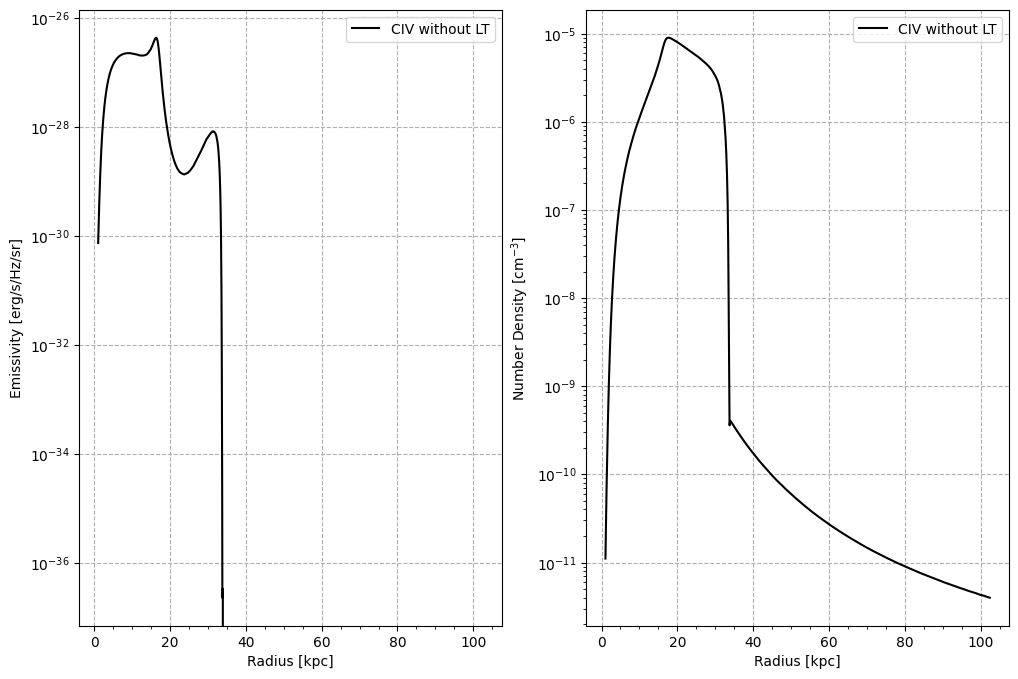

In [45]:
z = 0
red_shift_f = (1+z)**4
sr_to_arc = (180*3600 / np.pi)**2
fac = red_shift_f / sr_to_arc
fig= plt.figure(1,figsize=(12,8))
plt.subplot(1,2,1)


atom = 'HeII'
# plt.plot(cloudy_data_1[f'radius_{Lumin}'],cloudy_data_1[f'emis_{atom}_{Lumin}'],'r-',label=f'{atom} with LT')
# plt.plot(cloudy_data_2[f'radius_{Lumin}_{2}'],cloudy_data_2[f'emis_{atom}_{Lumin}'],'r--',label=f'{atom} without LT')
atom = 'CIV'
# plt.plot(cloudy_data_1[f'radius_{Lumin}'],cloudy_data_1[f'emis_{atom}_{Lumin}'],'b-',label=f'{atom} with LT')
plt.plot(cloudy_data_2[f'radius_{Lumin}'],cloudy_data_2[f'emis_{atom}_{Lumin}'],'k-',label=f'{atom} without LT')
# ax2.plot(cloudy_data_2[f'radius_{Lum}_{idx_2}'], cloudy_data_2[f'frac_CV_{Lum}_{idx_2}'],'r:',label = 'C V')
# ax2.plot(cloudy_data_2[f'radius_{Lum}_{idx_2}'], cloudy_data_2[f'frac_CIV_{Lum}_{idx_2}'],'g:',label = 'C IV')
# ax2.plot(cloudy_data_2[f'radius_{Lum}_{idx_2}'],cloudy_data_2[f'frac_CIII_{Lum}_{idx_2}'],'b:',label = 'C III')

plt.xlabel('Radius [kpc]')
plt.ylabel('Emissivity [erg/s/Hz/sr]')
plt.yscale('log')
plt.minorticks_on()
plt.grid(True,linestyle='--')

plt.legend()

plt.subplot(1,2,2)
# atom = 'HeII'
# plt.plot(cloudy_data_1[f'radius_{Lumin}'],cloudy_data_1[f'nden_{atom}_{Lumin}'],'r-',label=f'{atom} with LT')
# plt.plot(cloudy_data_2[f'radius_{Lumin}'],cloudy_data_2[f'nden_{atom}_{Lumin}'],'r--',label=f'{atom} without LT')
atom = 'CIV'
# plt.plot(cloudy_data_1[f'radius_{Lumin}'],cloudy_data_1[f'nden_{atom}_{Lumin}'],'b-',label=f'{atom} with LT')
plt.plot(cloudy_data_2[f'radius_{Lumin}'],cloudy_data_2[f'nden_{atom}_{Lumin}'],'k-',label=f'{atom} without LT')
plt.xlabel('Radius [kpc]')
plt.ylabel('Number Density [cm$^{-3}$]')
plt.yscale('log')

plt.minorticks_on()
plt.grid(True,linestyle='--')


plt.legend()


# print(f"HeI Luminosity = {cloudy_data_1[f'Lumin_HeI_{Lumin}_{idx}']:.4e} [erg/s]")

# f'Column_density_CIV_{Lumin}_{idx}'

# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/parameter', bbox_inches='tight')

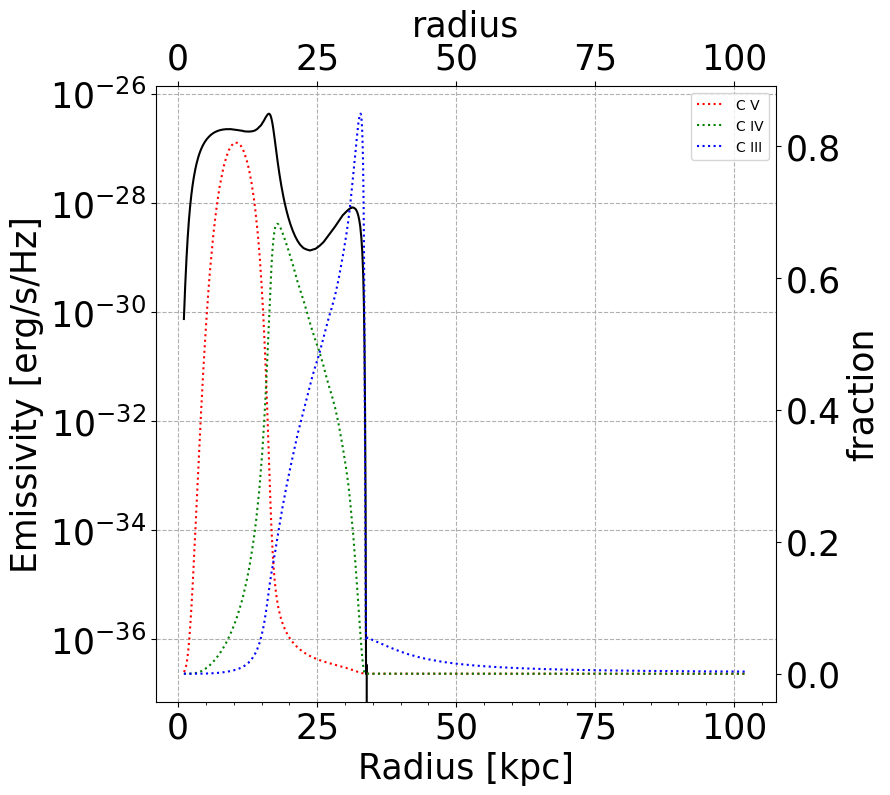

In [46]:
fig= plt.figure(1,figsize=(8,8))

gs = gridspec.GridSpec(1, 1)  #  , width_ratios=[1, 1],  wspace=0.55 

ax1 = fig.add_subplot(gs[0])

atom = 'HeII'
# plt.plot(cloudy_data_1[f'radius_{Lumin}'],cloudy_data_1[f'emis_{atom}_{Lumin}'],'r-',label=f'{atom} with LT')
# plt.plot(cloudy_data_2[f'radius_{Lumin}_{2}'],cloudy_data_2[f'emis_{atom}_{Lumin}'],'r--',label=f'{atom} without LT')
atom = 'CIV'
# plt.plot(cloudy_data_1[f'radius_{Lumin}'],cloudy_data_1[f'emis_{atom}_{Lumin}'],'b-',label=f'{atom} with LT')
ax1.plot(cloudy_data_2[f'radius_{Lumin}'],cloudy_data_2[f'emis_{atom}_{Lumin}'],'k-',label=f'{atom} without LT')

ax2 = fig.add_axes(ax1.get_position(), frameon=False)

ax2.plot(cloudy_data_2[f'radius_{Lumin}'], cloudy_data_2[f'frac_CV_{Lumin}'],'r:',label = 'C V')
ax2.plot(cloudy_data_2[f'radius_{Lumin}'], cloudy_data_2[f'frac_CIV_{Lumin}'],'g:',label = 'C IV')
ax2.plot(cloudy_data_2[f'radius_{Lumin}'],cloudy_data_2[f'frac_CIII_{Lumin}'],'b:',label = 'C III')

ax1.set_xlabel('Radius [kpc]',fontsize=25)
ax1.set_ylabel('Emissivity [erg/s/Hz]',fontsize=25)
ax1.tick_params(axis='both', labelsize=25)
# ax2.set_ylabel('fraction',fontsize=25)
ax1.set_yscale('log')

ax1.minorticks_on()
ax1.grid(True,linestyle='--')


ax2.xaxis.set_ticks_position('top')
ax2.xaxis.set_label_position('top')
ax2.set_xlabel('radius', fontsize=25)

ax2.yaxis.set_ticks_position('right')
ax2.yaxis.set_label_position('right')
ax2.set_ylabel('fraction', fontsize=25)
ax2.tick_params(axis='both', labelsize=25)

plt.legend()
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/parameter_fract', bbox_inches='tight')

Text(0, 0.5, '$\\rm SB(z) x (1+z)^4$ $\\rm [erg \\,s^{-1} \\, cm^{-2}]$ ')

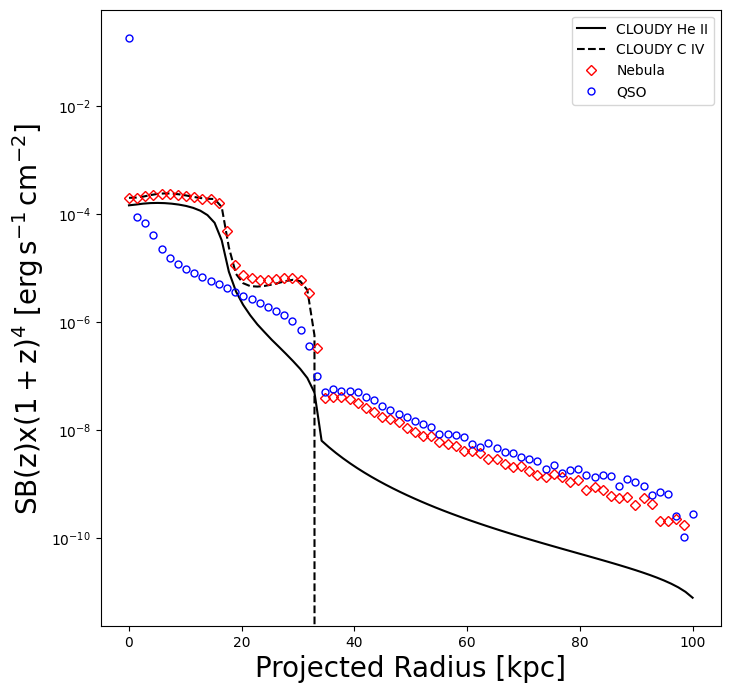

In [47]:
from RT_Function import *
fig = plt.figure(1,figsize=(8,8))

#Common 

z_red_shift = 0 
atom = 'CIV'
red_shift_f = (1+z_red_shift)**4
sr_to_arc = (180*3600 / np.pi)**2
fac = red_shift_f  #/ sr_to_arc
Lumin = 44.0
V_out = 500 
V_rand = 11.8

#CLOUDY
Geometry_Te = 'Test'
V_emit_Te = 1.0
radius_Te_W_LT = RT_make_parameter(z_red_shift,V_out, V_emit_Te, V_rand, Geometry_Te, atom, Lumin,idx_1,metals,Column_density_order)[0]
Num_SB_Te_W_LT = RT_make_parameter(z_red_shift,V_out, V_emit_Te, V_rand, Geometry_Te, atom, Lumin,idx_1,metals,Column_density_order)[3]
# number_dist_W_LT, SB_Te_W_LT = photon_number_SB(radius_Te_W_LT,Num_SB_Te_W_LT,cloudy_data_1[f'Lumin_{atom}_{Lumin}']) 

radius_Te_WO_LT = RT_make_parameter(z_red_shift,V_out, V_emit_Te, V_rand, Geometry_Te, atom, Lumin,idx_2,metals,Column_density_order)[0]
Num_SB_Te_WO_LT = RT_make_parameter(z_red_shift,V_out, V_emit_Te, V_rand, Geometry_Te, atom, Lumin,idx_2,metals,Column_density_order)[3]
# number_dist_WO_LT, SB_Te_WO_LT = photon_number_SB(radius_Te_WO_LT,Num_SB_Te_WO_LT,cloudy_data_2[f'Lumin_{atom}_{Lumin}']) 

radius_Te_W_LT, SB_Te_W_LT = cloudy_data_1[f'radius_p_{Lumin}'] , cloudy_data_1[f'SB_{atom}_{Lumin}']
radius_Te_WO_LT, SB_Te_WO_LT = cloudy_data_2[f'radius_p_{Lumin}'] , cloudy_data_2[f'SB_{atom}_{Lumin}']

radius_Te_WO_LT, SB_Te_WO_LT_HeII = cloudy_data_2[f'radius_p_{Lumin}'] , cloudy_data_2[f'SB_HeII_{Lumin}']

#Nebula
Geometry_Ne = 'Nebula'
V_emit_Ne = 3000
radius_Ne = RT_make_parameter(z_red_shift,V_out, V_emit_Ne, V_rand, Geometry_Ne, atom, Lumin,idx_2,metals,Column_density_order)[0]
Num_SB_Ne = RT_make_parameter(z_red_shift,V_out, V_emit_Ne, V_rand, Geometry_Ne, atom, Lumin,idx_2,metals,Column_density_order)[3]
number_dist_Ne, SB_Ne = photon_number_SB(radius_Ne,Num_SB_Ne ,cloudy_data_2[f'Lumin_{atom}_{Lumin}']) 

#QSO
Geometry_Q = 'QSO'
V_emit_Q = 3000
radius_Q = RT_make_parameter(z_red_shift,V_out, V_emit_Q, V_rand, Geometry_Q, atom, Lumin,idx_2,metals,Column_density_order)[0]
Num_SB_Q = RT_make_parameter(z_red_shift,V_out, V_emit_Q, V_rand, Geometry_Q, atom, Lumin,idx_2,metals,Column_density_order)[3]
number_dist_Q, SB_Q = photon_number_SB(radius_Q,Num_SB_Q ,CIV_total_flux_QSO)  # CIV_total_flux_QSO


# plt.plot(radius_from_CLOUDY,SB_from_CLOUDY )
# plt.plot(radius_Te_W_LT,SB_Te_W_LT,'k--',label='CLOUDY_W_LT')
plt.plot(radius_Te_WO_LT, SB_Te_WO_LT_HeII,'k-',label='CLOUDY He II')
plt.plot(radius_Te_WO_LT,SB_Te_WO_LT,'k--',label='CLOUDY C IV')
plt.plot(radius_Ne,SB_Ne,marker='D',color='r',linestyle='', markersize=5, markerfacecolor='none', label=f'Nebula') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'
plt.plot(radius_Q,SB_Q,marker='o',color='b',linestyle='', markersize=5, markerfacecolor='none', label=f'QSO') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$

# plt.plot(radius_Ne,SB_Ne + SB_Q,marker='X',color='k',linestyle='', markersize=5, markerfacecolor='none', label=f'Nebula + QSO') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$'
# plt.plot(radius_Q,SB_Q,marker='o',color='b',linestyle='', markersize=5, markerfacecolor='none', label=f'QSO') # -$\\rm V_{{\\rm out}}$ = {V_out} ${{\\rm km \\,s ^{{-1}}}}$

plt.yscale('log')

plt.legend()

plt.xlabel('Projected Radius [kpc]', fontsize=20)
plt.ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2}]$ ', fontsize=20)
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/RT_result_SB', bbox_inches='tight')

In [50]:
from DATA_CHECK import *


path_d = '/home/jin/data_CIV'


style ='radi'


# ----- Common -----
V_out  = 500 
V_emit = 1000
V_rand = 11.8
# ----- Common -----

# ----- Data -----
# atom_num, atom_index = 32 , 15
# path_Data = Data_path(path_d,style, atom_num, atom_index , V_out, V_emit, V_rand)
# print(path_Data)
# ----- Data -----

#------ SB --------
Geometry = 3  # 1 = Test , 2 = Nebula , 3 = QSO, 4 = AGN_con, 5 = Flat
atom = 'CIV'
path_s = '/home/jin/RT/RT_scat'
data_file = 'CLOUDY'
Lumin = 44.0 
idx = 2
metals = 1.0
Column_density_order = 22.0




path_SB =RT_CLOUDY_path(path_s,data_file,V_out, V_emit, V_rand, Geometry, atom, Lumin,idx,metals,Column_density_order)
print(path_SB)
#------ SB --------


/home/jin/RT/RT_scat/WOCIVL440M1NH220/N_atom300E+10_Vexp500E+02_Vemit100E+03_tauD000E+00_Vran118E+01


In [ ]:
V_out  = 0
V_emit = 3000
V_rand = 0
Geometry = 3  # 1 = Test , 2 = Nebula , 3 = QSO, 4 = AGN_con, 5 = Flat
atom = 'CIV'
path_s = '/home/jin/RT/RT_scat/test_QSO'
data_file = 'SB'
path_SB = RT_CLOUDY_path(path_s,data_file,V_out, V_emit, V_rand, Geometry, atom, Lumin,idx,metals,Column_density_order)

lam, spec_tot, spec_sc = spec_com(path_SB)
print(f'{np.sum(spec_tot):.2e}')
plt.plot(lam,spec_tot,'b-')

Geometry = 1

path_SB = RT_CLOUDY_path(path_s,data_file,V_out, V_emit, V_rand, Geometry, atom, Lumin,idx,metals,Column_density_order)

lam, spec_tot, spec_sc = spec_com(path_SB)
print(f'{np.sum(spec_tot):.2e}')
plt.plot(lam,spec_tot,'k--')